# 六面包围：均匀背景＋球状异常体

本Notebook包含真实保存结果与可执行复绘代码。配套FWI Python脚本已在四张A30完成；下面CPU单元实际执行，图像嵌入输出。整体目录可移动，保持results/相对路径。

100 epochs，训练94.13s；RMSE 39.486→4.413m/s。

六面包围清楚恢复异常体，但采集照明是理想化的。


In [1]:
from pathlib import Path
import json, numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / 'case_manifest.json').is_file(), 'Open from delivered folder'
CASE = 'enclosed'
RESULTS = ROOT / 'results' / CASE
summary = json.loads((RESULTS / 'summary.json').read_text())
print(json.dumps({k: summary[k] for k in ('status','completed_epochs','training_seconds','gpu_memory','initial','final','quality_checks')},ensure_ascii=False,indent=2))

{
  "status": "COMPLETED",
  "completed_epochs": 100,
  "training_seconds": 94.13165600399952,
  "gpu_memory": {
    "2": {
      "allocated_MiB": 113.85107421875,
      "reserved_MiB": 132.0
    },
    "0": {
      "allocated_MiB": 101.0859375,
      "reserved_MiB": 124.0
    },
    "1": {
      "allocated_MiB": 101.0859375,
      "reserved_MiB": 124.0
    },
    "3": {
      "allocated_MiB": 101.0859375,
      "reserved_MiB": 124.0
    }
  },
  "initial": {
    "epoch": 0,
    "fixed_model_normalized_mse": 0.011807399801909924,
    "rmse_m_s": 39.48633576266519,
    "interior_rmse_m_s": 50.16711985664794,
    "elapsed_seconds": 0.49405823899724055,
    "contrast_relative_l2": 1.0,
    "contrast_correlation": 0.0,
    "anomaly_rmse_m_s": 235.80761700653355,
    "central_recovered_contrast_m_s": 0.0,
    "maximum_recovered_contrast_m_s": 0.0,
    "recovered_centroid_xyz_m": null,
    "centroid_distance_m": null
  },
  "final": {
    "epoch": 100,
    "fixed_model_normalized_mse": 2.464

## 梯度正确性

2/4/6/8阶full/boundary、4阶内部方向中心有限差分，以及相同四炮的单卡/四卡比较。阈值和数值全部保留。

In [2]:
checks = json.loads((RESULTS / 'numerical_checks.json').read_text())
assert checks['status'] == 'PASSED'
print(json.dumps(checks,ensure_ascii=False,indent=2))
print((RESULTS / 'gradients' / 'gradient_manifest.json').read_text())

{
  "status": "PASSED",
  "checks": [
    {
      "check": "full_vs_boundary",
      "accuracy": 2,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 7.14217851149455e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "full_vs_boundary",
      "accuracy": 4,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 4.513145522561239e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "full_vs_boundary",
      "accuracy": 6,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 6.005102093770098e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "full_vs_boundary",
      "accuracy": 8,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 5.191972923667195e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "model_directional_derivative",
      "accuracy": 4,
 

## 观测系统、模型、收敛和中间梯度

CPU重新绘图，未平滑结果。梯度既有独立归一化图，也有共同原始色标图。

In [3]:
from render_scalar3d import render_case
figure_files = render_case(RESULTS)
print('Re-rendered:',figure_files)

Re-rendered: ['convergence.png', 'gradients_normalized.png', 'shot_gather.png', 'model_3d.png', 'gradients_shared_scale.png', 'model_comparison.png', 'acquisition.png']


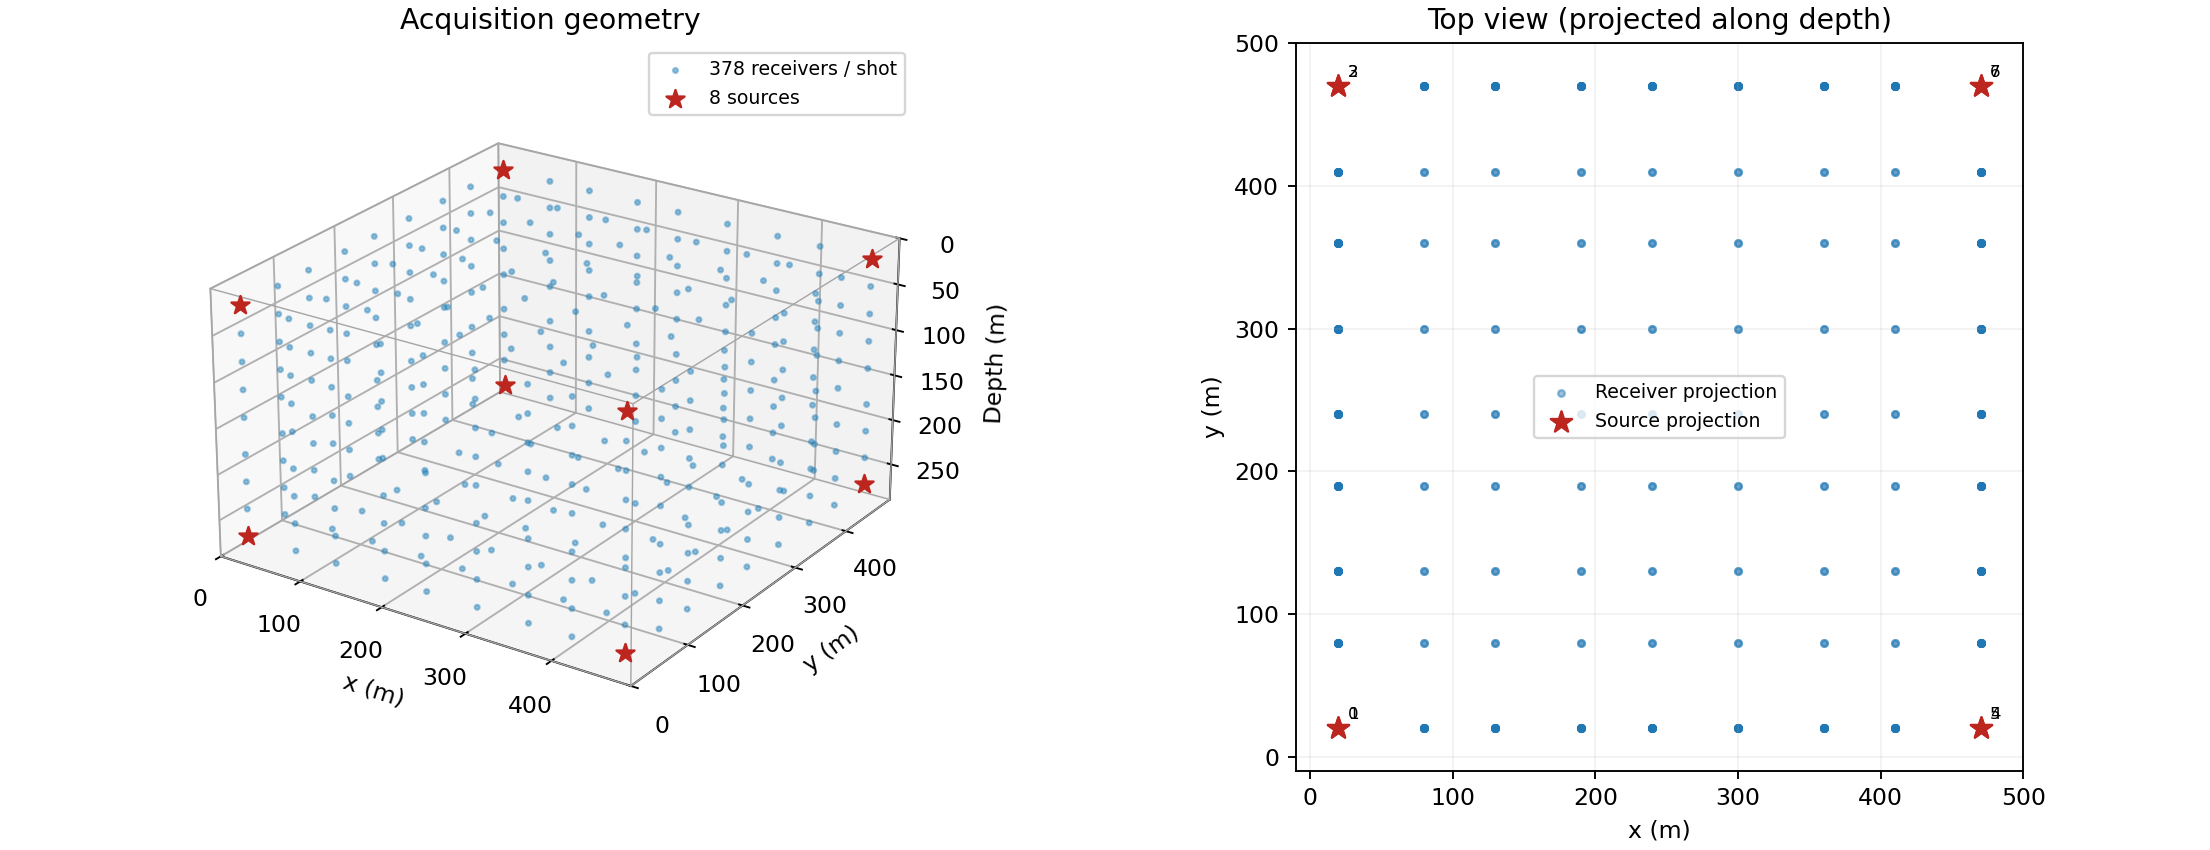

In [4]:
display(Image(filename=str(RESULTS / 'acquisition.png')))

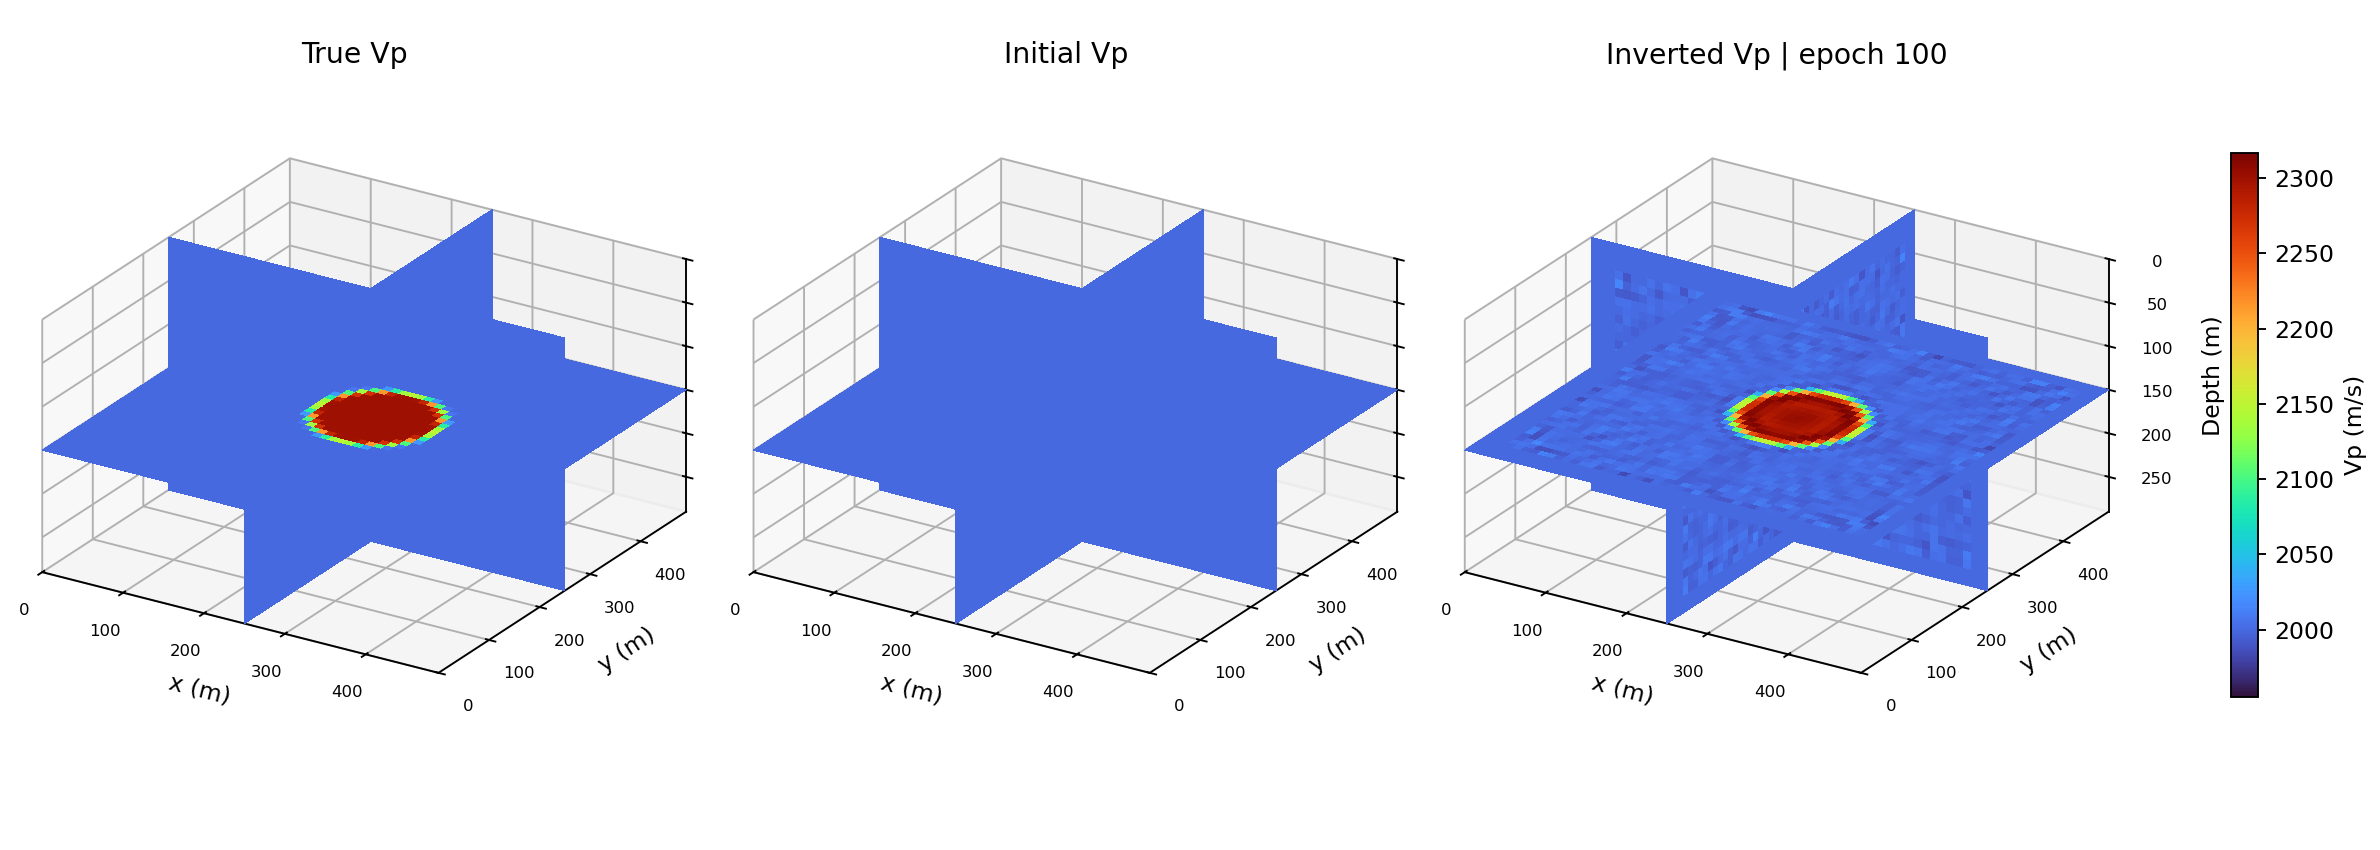

In [5]:
display(Image(filename=str(RESULTS / 'model_3d.png')))

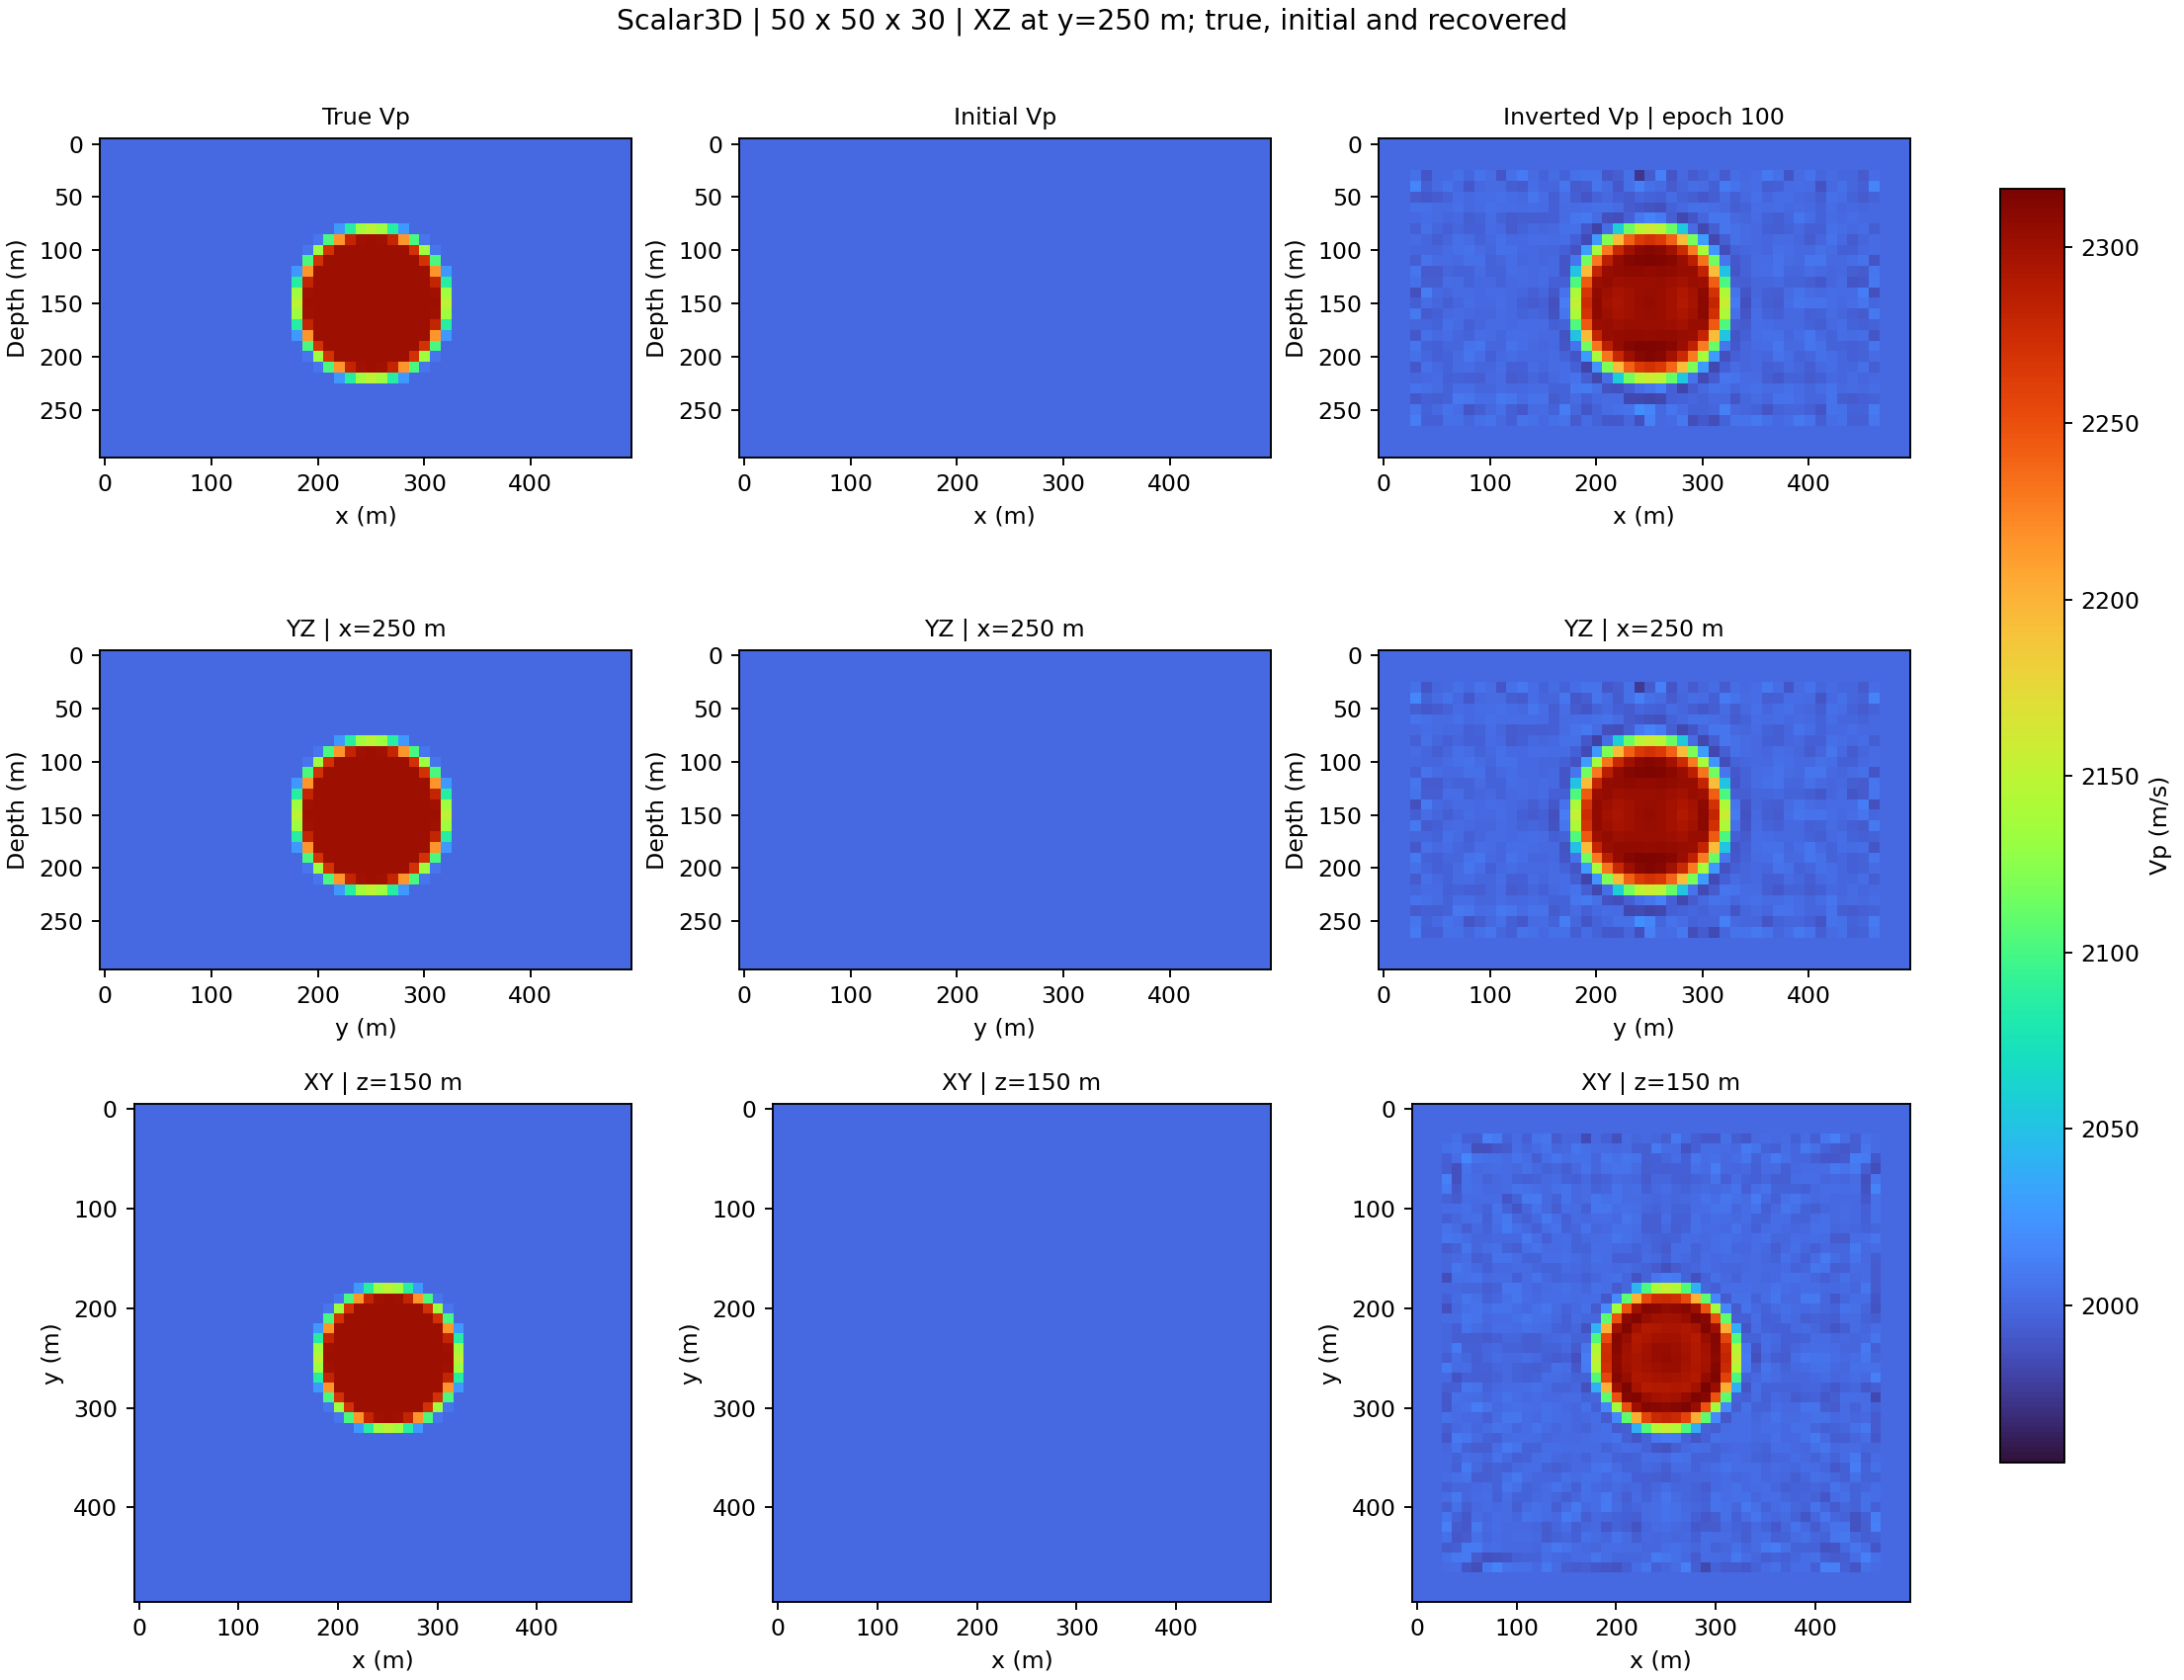

In [6]:
display(Image(filename=str(RESULTS / 'model_comparison.png')))

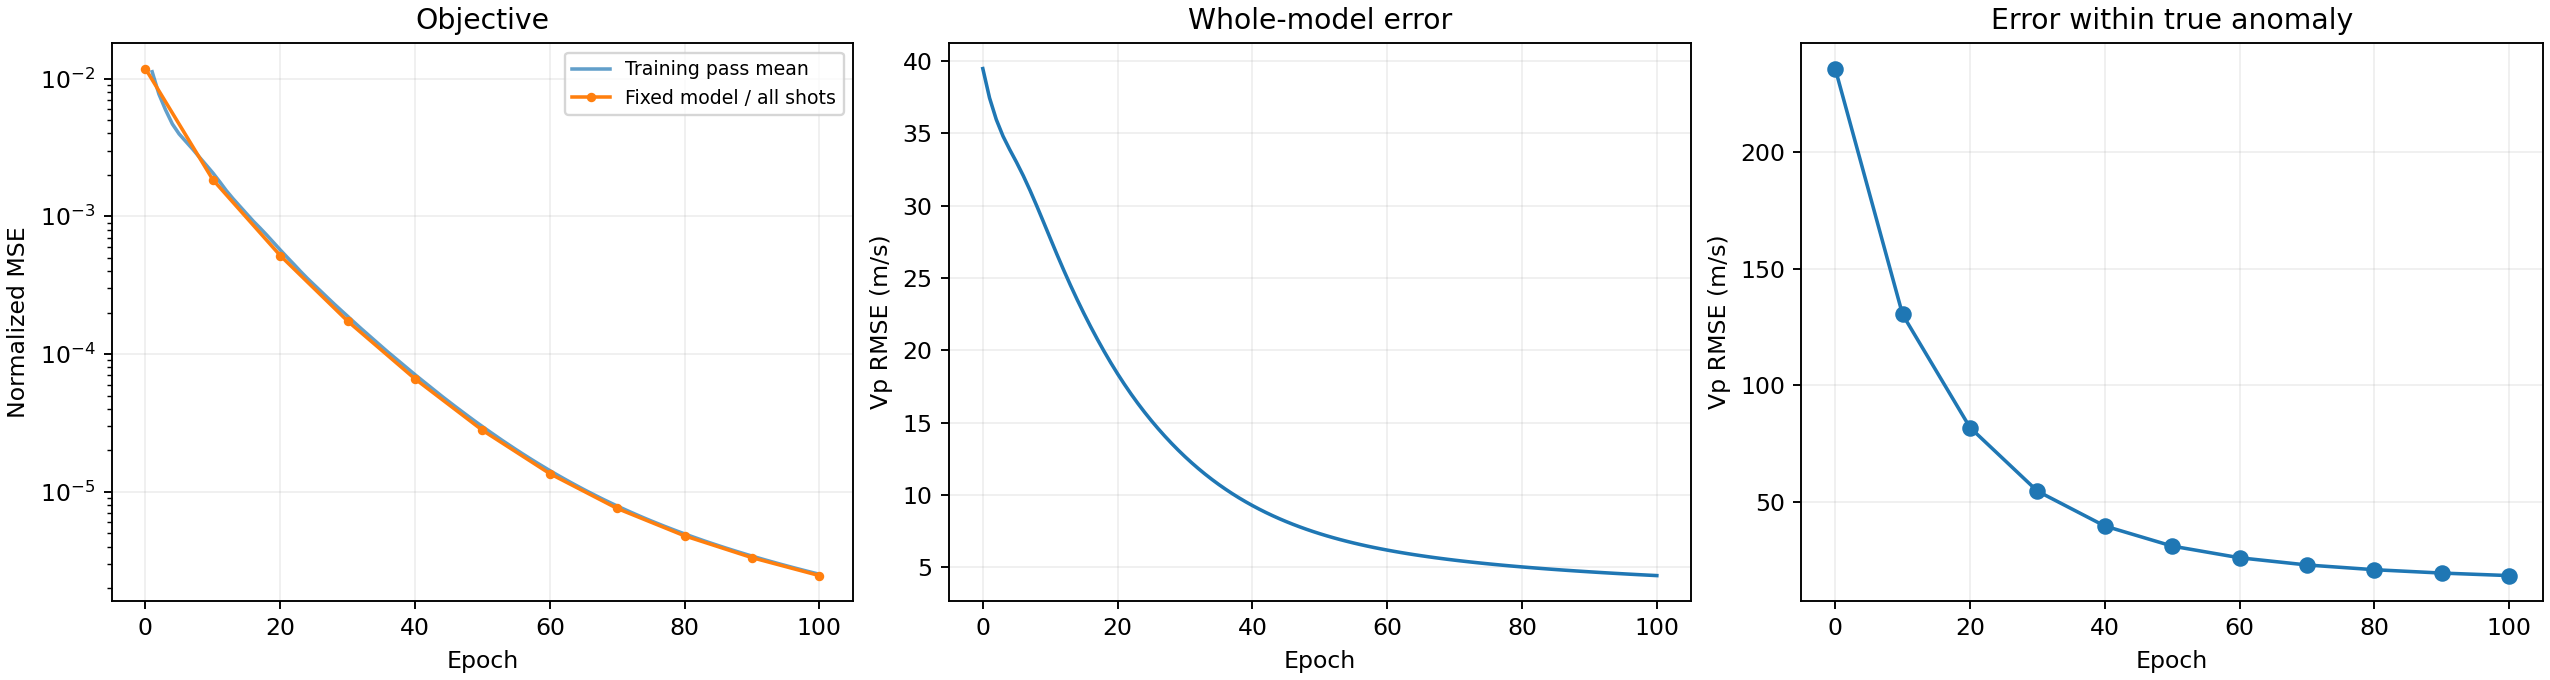

In [7]:
display(Image(filename=str(RESULTS / 'convergence.png')))

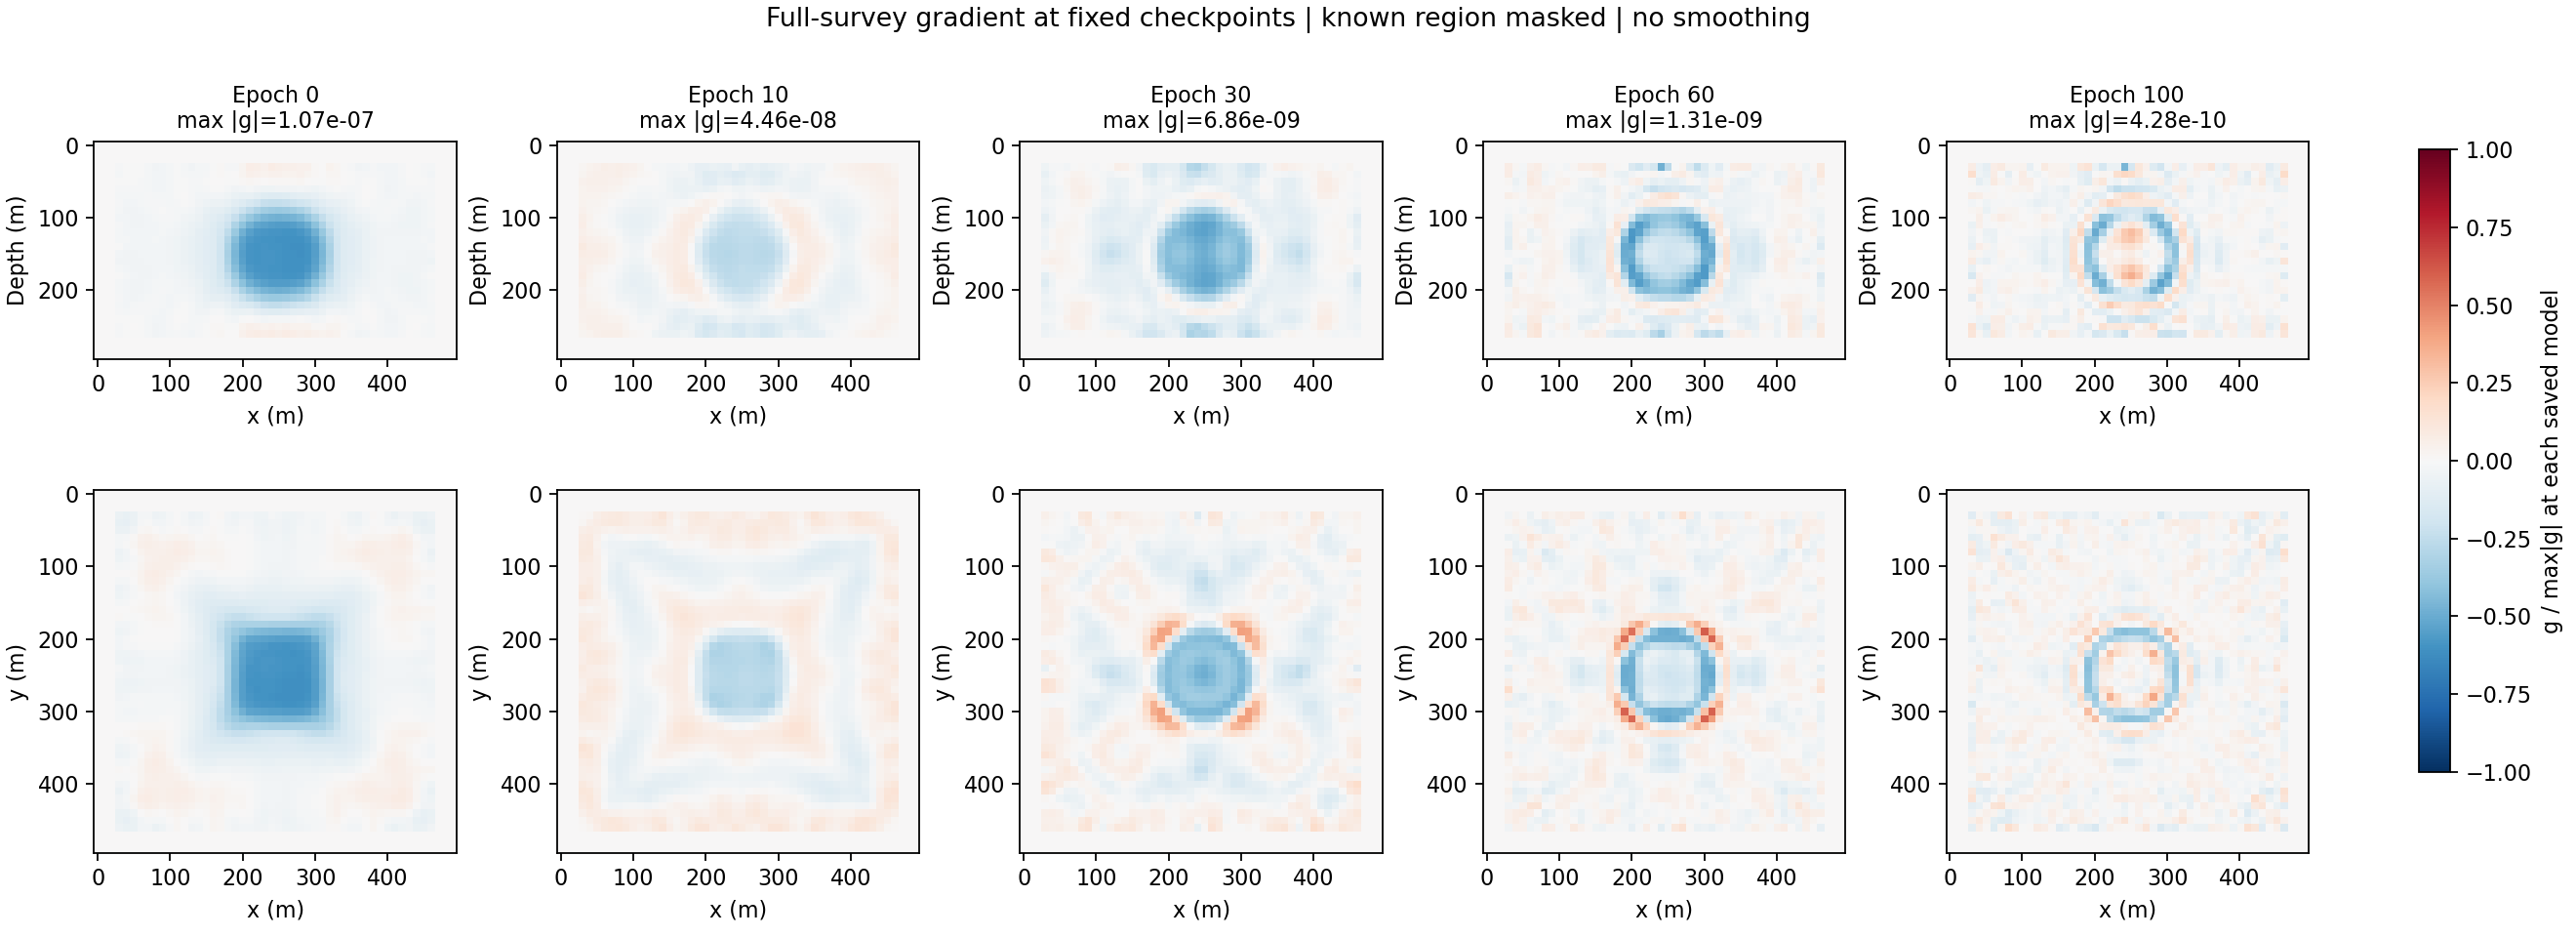

In [8]:
display(Image(filename=str(RESULTS / 'gradients_normalized.png')))

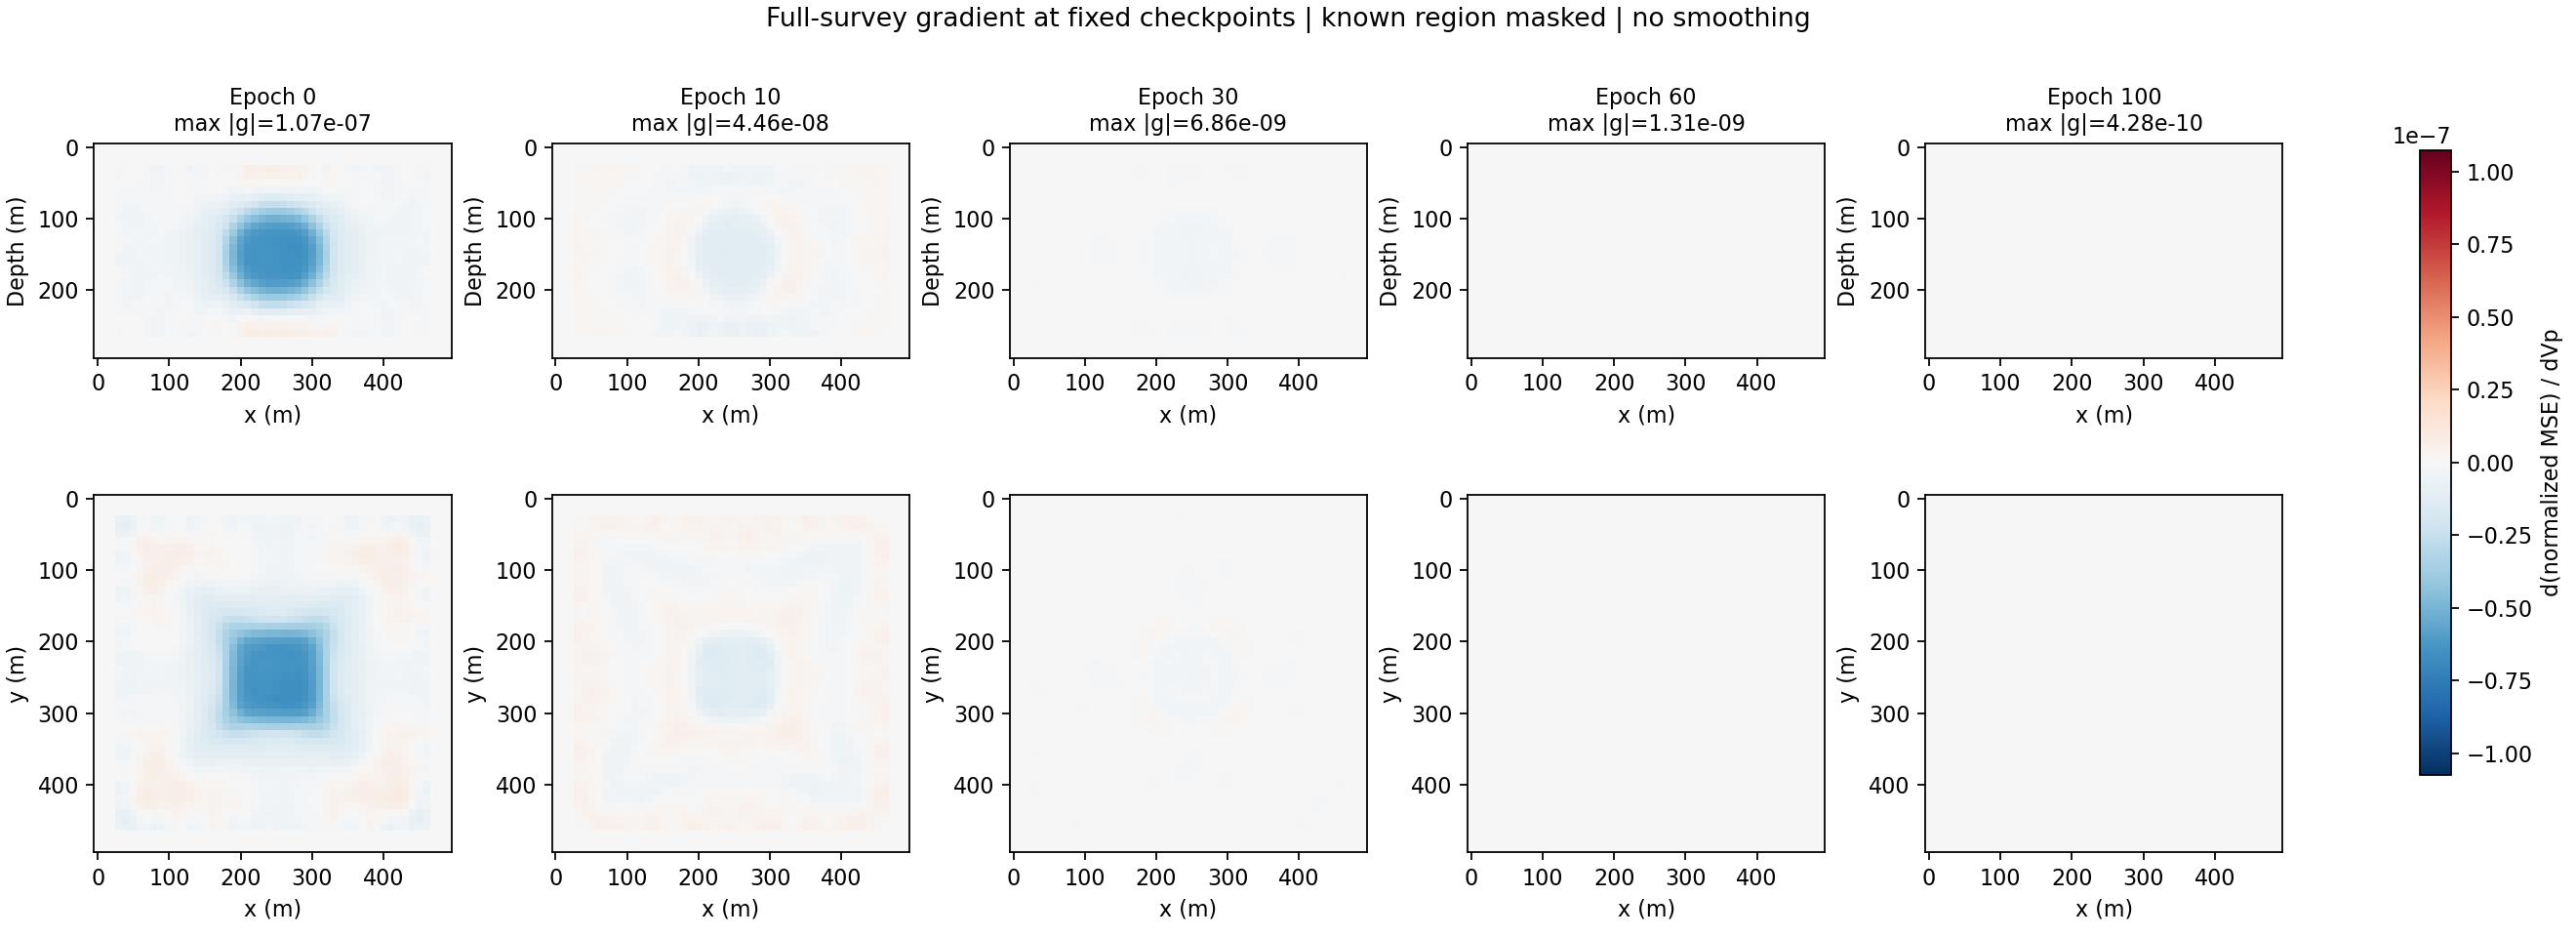

In [9]:
display(Image(filename=str(RESULTS / 'gradients_shared_scale.png')))

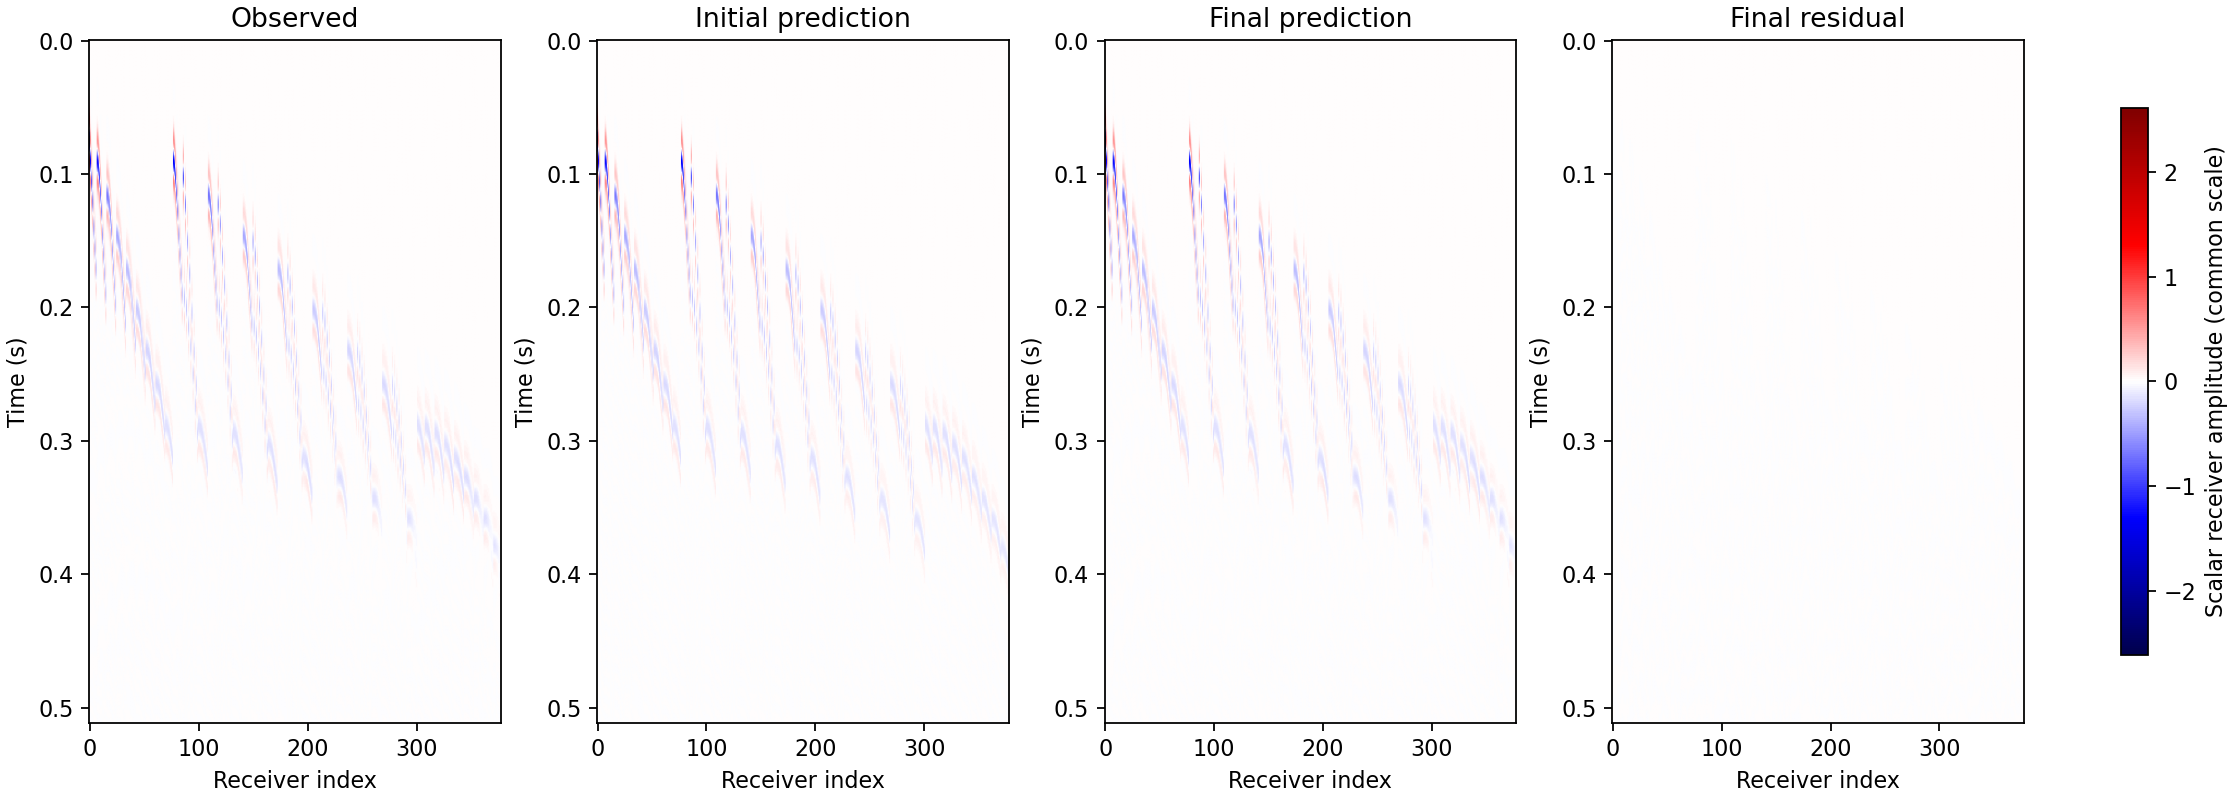

In [10]:
display(Image(filename=str(RESULTS / 'shot_gather.png')))

## 可选：完整CUDA重跑

默认关闭，避免打开报告就开始训练。设置已编译V11路径、新输出目录和GPU_IDS，然后把RUN_FWI改True。不会自动安装、编译或覆盖已有结果。

In [11]:
RUN_FWI = False
SOURCE_ROOT = Path('/path/to/compiled/StarWave')
GPU_IDS = '2,0,1,3'
NEW_RESULTS = ROOT / ('rerun_' + CASE)
if RUN_FWI:
    import subprocess, sys
    subprocess.run([sys.executable,str(ROOT/'run_scalar3d_example.py'),'--case',CASE,
                    '--source-root',str(SOURCE_ROOT),'--output-dir',str(NEW_RESULTS),
                    '--gpu-ids',GPU_IDS],check=True)
else:
    print('Saved-result cells executed. Optional CUDA re-run disabled.')

Saved-result cells executed. Optional CUDA re-run disabled.
